# Main notebook

This notebook contains all the workflow needed to execute and evaluate the models.

The best weights for each models are saved in the `best_models` folder.

The graphs for the evolution of metrics during the training process are saved in the `graphs` folder.

The hyperparameters for each model are selected beforehand. They have been chosen guided by the 'optimization' notebook.

There are 4 models to train, they are defined in the `ff`, `cnn`, `vit` python files for FeedForward network, convolutional neural network and vision transformer models and in `ptst_modeling`, inside the transformers folder, for the PatchTST model.

In [ ]:
# Copyright 2025 Alejandro Moreno Guerrero

# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at

#     http://www.apache.org/licenses/LICENSE-2.0

# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torch.nn.functional as F
import matplotlib.pyplot as plt
import get_dataset
import cnn
import vit
import ff
import transformers.models.patchtst.modeling_patchtst as ptst_modeling
import transformers.models.patchtst.configuration_patchtst as ptst_config
import importlib
from einops import rearrange
from bayes_opt import BayesianOptimization
from matplotlib.ticker import MaxNLocator
from time import time
import os

torch.manual_seed(42)

In [33]:
PATH_D = "Series temporales/DNI/" # path to data
NUM_S = 3 # number of sensors
SENSORS = ["S1", "S3", "S4"] # sensors names

CPU is the device selected for the training of the models. It is not recommended to use other accelerator, at least for this dataset

In [34]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
device = "cpu"
print(f"Using {device} device")

Using cpu device


In [35]:
# training loop
def train_loop(dataloader, model, loss_fn, optimizer):

    t1 = time()
    model.train()
    patchtst = model.name == "PatchTST"

    for batch, (X, y) in enumerate(dataloader):
        if patchtst:
            X = rearrange(X, 'b c s -> b s c')

        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    t2 = time()
    return t2 - t1

# testing loop
def test_loop(dataloader, model, loss_fn, threshold, verbose=True):

    t1 = time()
    model.eval()
    patchtst = model.name == "PatchTST"
    num_batches = len(dataloader)
    positive_real, positive_pred, test_loss, correct, correct_pos = 0, 0, 0, 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            if patchtst:
                X = rearrange(X, 'b c s -> b s c')
 
            pred = model(X)
            loss = loss_fn(pred, y).item()
            
            test_loss += loss  

            pred_pos = torch.where(F.sigmoid(pred) > threshold, 1, 0)
            real_pos = (y == 1.0)

            positive_pred += pred_pos.type(torch.float).sum().item()
            positive_real += y.type(torch.float).sum().item()
            correct_pos += torch.bitwise_and(pred_pos,real_pos).type(torch.float).sum().item()
            correct += (pred_pos == y).type(torch.float).sum().item()


    test_loss /= num_batches
    correct /= 3*num_batches*dataloader.batch_size
    if (positive_pred != 0):
        precission = correct_pos/positive_pred
    else:
        precission = 0.0
    if (positive_real != 0):
        recall = correct_pos/positive_real
    else:
        recall = 0.0
    if (precission+recall > 0):
        f1score = 2*precission*recall/(precission+recall)
    else:
        f1score = 0

    if (verbose):
        print(f"Accuracy: \t {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f}")
        print(f"Precission: \t {(100*precission):>0.1f}%")
        print(f"Recall: \t {(100*recall):>0.1f}%")
        print(f"F1-score: \t {(f1score):>0.3f}")

    t2 = time()
    return test_loss, correct, precission, recall, f1score, t2-t1


In [36]:
def pintar_grafico(ax,epochs,ys,best_epoch,title,labels=[""]):
    # function used to draw each individual graph for a metric
    # during the training of the model

    x = range(1,1+epochs)
    for i in range(len(ys)):
        ax.plot(x,ys[i][0,:], label=labels[i]+"training")
        ax.plot(x,ys[i][1,:], label=labels[i]+"validation")
        ax.set_ylim(0.0,1.02)
        ax.set_xlabel("epoch")
        ax.set_title(title)
        ax.set_xticks(np.arange(1, epochs+1, 1))
        ax.set_yticks(np.arange(0, 1.02, 0.1))
        ax.set_yticks(np.arange(0, 1.02, 0.025), minor=True)
        ax.grid(which='major', linestyle='-', linewidth=0.8, color='gray')
        ax.grid(which='minor', linestyle=':', linewidth=0.5, color='gray')
        ax.axvline(best_epoch,color='purple')
        ax.legend()
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))

In [37]:
def show_metrics(epochs, loss, accuracy, precission, recall, f1, best_epoch, name):
    # function that draws all the graphs for the training metrics

    fig, ax = plt.subplots(2,2,figsize=(8,8))
    pintar_grafico(ax[0,0], epochs, [accuracy], best_epoch, "accuracy "+name)
    pintar_grafico(ax[0,1], epochs, [precission], best_epoch, "precission "+name)
    pintar_grafico(ax[1,0], epochs, [recall], best_epoch, "recall "+name)
    pintar_grafico(ax[1,1], epochs, [f1, loss], best_epoch, "f1 y loss "+ name,["f1 ", "loss "])

    fig.tight_layout()
    if not os.path.exists('training_graphs/graficas ' + name + '.svg'):
        plt.savefig('training_graphs/graficas ' + name + '.svg')
    plt.show()

In [38]:
batch_size = 16
importlib.reload(get_dataset)
train_ds, test_ds, val_ds, weights = get_dataset.get_dataset(0.20,0.20,sequential=False,coef_weights=1,random_state=42,device=device)

Categorías entrenamiento:
[0 1 2 3 4 5 6 7]
[855 143 186   3 203   7  17   8]
Categorías validación:
[0 1 2 3 4 5 6 7]
[285  47  62   1  67   3   6   3]
Categorías test:
[0 1 2 3 4 5 6 7]
[286  48  62   1  68   2   6   2]


In [39]:
train_loader = DataLoader(train_ds,batch_size=batch_size,shuffle=False,drop_last=True)
test_loader = DataLoader(test_ds,batch_size=batch_size,shuffle=False,drop_last=True)
val_loader = DataLoader(val_ds,batch_size=batch_size,shuffle=False,drop_last=True)

MODEL: FF
Epoch 1
-------------------------------
Training dataset:
Accuracy: 	 84.7%, Avg loss: 0.768461
Precission: 	 48.1%
Recall: 	 78.0%
F1-score: 	 0.595

Validation dataset:
Accuracy: 	 84.7%, Avg loss: 0.774050
Precission: 	 48.1%
Recall: 	 77.6%
F1-score: 	 0.594

Epoch 2
-------------------------------
Training dataset:
Accuracy: 	 93.4%, Avg loss: 0.678875
Precission: 	 78.3%
Recall: 	 74.7%
F1-score: 	 0.764

Validation dataset:
Accuracy: 	 92.1%, Avg loss: 0.706000
Precission: 	 72.6%
Recall: 	 72.6%
F1-score: 	 0.726

Epoch 3
-------------------------------
Training dataset:
Accuracy: 	 94.1%, Avg loss: 0.635063
Precission: 	 83.4%
Recall: 	 73.4%
F1-score: 	 0.780

Validation dataset:
Accuracy: 	 93.8%, Avg loss: 0.657223
Precission: 	 82.8%
Recall: 	 71.6%
F1-score: 	 0.768

Epoch 4
-------------------------------
Training dataset:
Accuracy: 	 93.2%, Avg loss: 0.645048
Precission: 	 77.2%
Recall: 	 74.8%
F1-score: 	 0.760

Validation dataset:
Accuracy: 	 92.8%, Avg loss

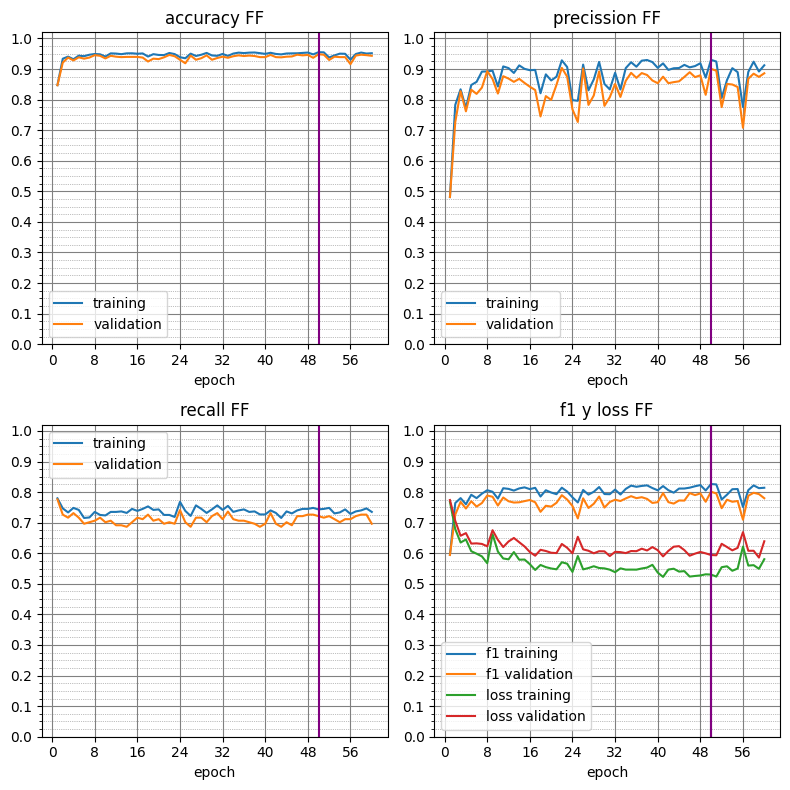

MODEL: CNN
Epoch 1
-------------------------------
Training dataset:
Accuracy: 	 37.6%, Avg loss: 1.197906
Precission: 	 14.0%
Recall: 	 64.8%
F1-score: 	 0.230

Validation dataset:
Accuracy: 	 37.7%, Avg loss: 1.196943
Precission: 	 14.1%
Recall: 	 65.2%
F1-score: 	 0.232

Epoch 2
-------------------------------
Training dataset:
Accuracy: 	 46.9%, Avg loss: 1.034428
Precission: 	 19.2%
Recall: 	 83.7%
F1-score: 	 0.312

Validation dataset:
Accuracy: 	 47.7%, Avg loss: 0.998479
Precission: 	 20.0%
Recall: 	 87.1%
F1-score: 	 0.325

Epoch 3
-------------------------------
Training dataset:
Accuracy: 	 80.8%, Avg loss: 0.675965
Precission: 	 41.7%
Recall: 	 84.2%
F1-score: 	 0.557

Validation dataset:
Accuracy: 	 81.3%, Avg loss: 0.757327
Precission: 	 42.4%
Recall: 	 82.1%
F1-score: 	 0.559

Epoch 4
-------------------------------
Training dataset:
Accuracy: 	 85.1%, Avg loss: 0.573907
Precission: 	 49.1%
Recall: 	 85.5%
F1-score: 	 0.624

Validation dataset:
Accuracy: 	 85.7%, Avg los

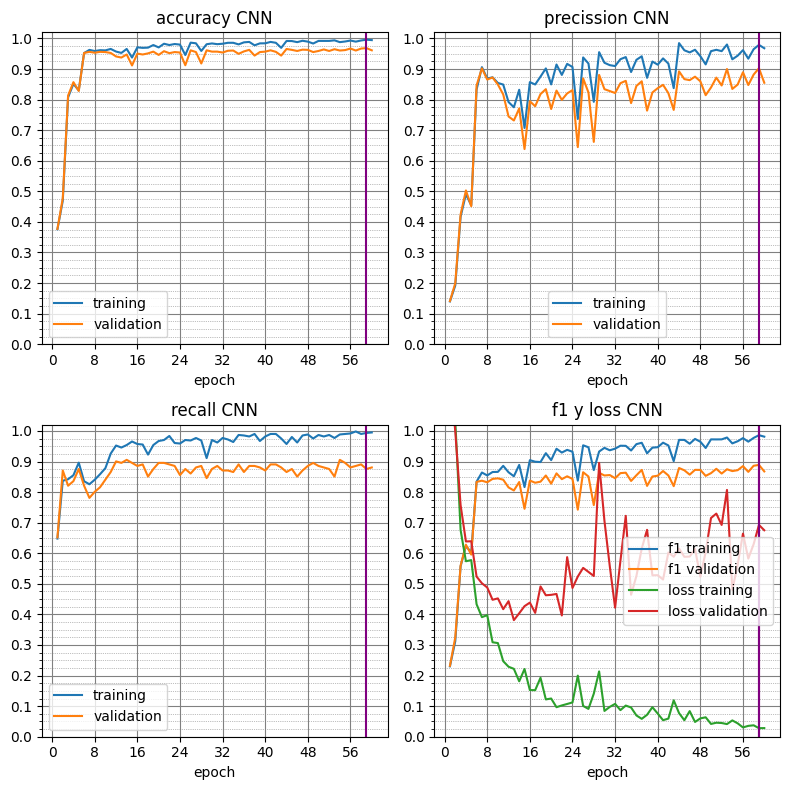

MODEL: ViT
Epoch 1
-------------------------------
Training dataset:
Accuracy: 	 74.3%, Avg loss: 0.825538
Precission: 	 34.2%
Recall: 	 85.5%
F1-score: 	 0.489

Validation dataset:
Accuracy: 	 72.1%, Avg loss: 0.861481
Precission: 	 32.0%
Recall: 	 83.1%
F1-score: 	 0.462

Epoch 2
-------------------------------
Training dataset:
Accuracy: 	 80.8%, Avg loss: 0.743521
Precission: 	 41.9%
Recall: 	 86.2%
F1-score: 	 0.564

Validation dataset:
Accuracy: 	 78.7%, Avg loss: 0.795140
Precission: 	 38.9%
Recall: 	 83.6%
F1-score: 	 0.531

Epoch 3
-------------------------------
Training dataset:
Accuracy: 	 85.2%, Avg loss: 0.672696
Precission: 	 49.2%
Recall: 	 85.7%
F1-score: 	 0.625

Validation dataset:
Accuracy: 	 84.3%, Avg loss: 0.733295
Precission: 	 47.6%
Recall: 	 83.1%
F1-score: 	 0.605

Epoch 4
-------------------------------
Training dataset:
Accuracy: 	 87.5%, Avg loss: 0.608276
Precission: 	 54.2%
Recall: 	 86.5%
F1-score: 	 0.666

Validation dataset:
Accuracy: 	 87.6%, Avg los

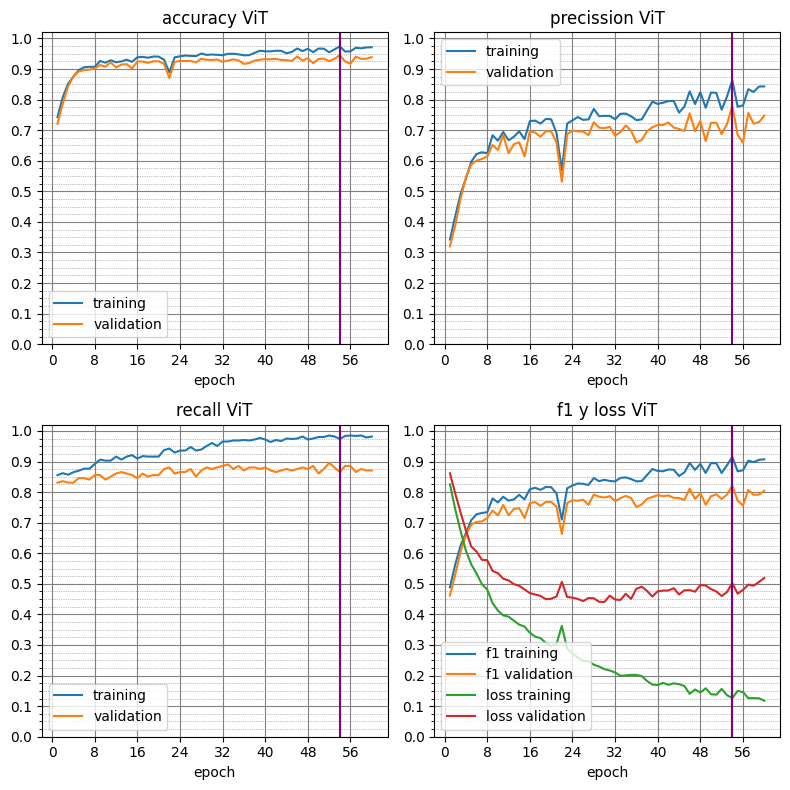

MODEL: PatchTST
Epoch 1
-------------------------------
Training dataset:
Accuracy: 	 84.1%, Avg loss: 0.980817
Precission: 	 46.2%
Recall: 	 62.3%
F1-score: 	 0.530

Validation dataset:
Accuracy: 	 85.5%, Avg loss: 1.039893
Precission: 	 49.8%
Recall: 	 57.2%
F1-score: 	 0.532

Epoch 2
-------------------------------
Training dataset:
Accuracy: 	 90.0%, Avg loss: 0.639298
Precission: 	 62.3%
Recall: 	 76.8%
F1-score: 	 0.688

Validation dataset:
Accuracy: 	 90.4%, Avg loss: 0.685034
Precission: 	 64.5%
Recall: 	 74.1%
F1-score: 	 0.690

Epoch 3
-------------------------------
Training dataset:
Accuracy: 	 92.6%, Avg loss: 0.538509
Precission: 	 72.1%
Recall: 	 79.1%
F1-score: 	 0.755

Validation dataset:
Accuracy: 	 92.5%, Avg loss: 0.570235
Precission: 	 73.0%
Recall: 	 76.6%
F1-score: 	 0.748

Epoch 4
-------------------------------
Training dataset:
Accuracy: 	 94.1%, Avg loss: 0.470981
Precission: 	 79.1%
Recall: 	 80.4%
F1-score: 	 0.798

Validation dataset:
Accuracy: 	 93.5%, Av

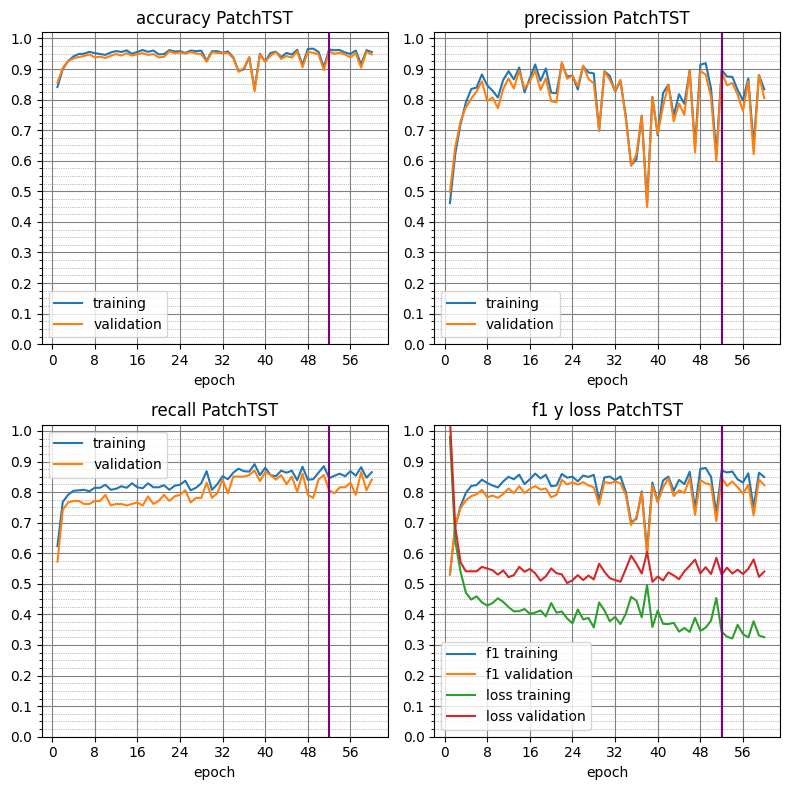

In [40]:
importlib.reload(cnn)
importlib.reload(vit)
importlib.reload(ff)

models = [] # list of all models to train and evaluate

models.append((ff.FF(
    num_sensors=NUM_S,
    layer1=200,
    layer2=200
).to(device),0.5,0.001))


models.append((cnn.CNN(
    num_sensors=NUM_S,
    batch_size=batch_size,
    channels=[4,3,2],
    kernels=[4,4,4],
    dense=[200,13]
    ).to(device),0.5,0.001))


models.append((vit.ViT(
    series_length=144,
    patch_length=6,
    num_sensors=NUM_S,
    dim=12,
    depth=4,
    heads=4,
    dim_head=7,
    mlp_dim=7,
    dropout=0.1,
    emb_dropout=0.1,
).to(device),0.5,0.001))


config = ptst_config.PatchTSTConfig(
    num_input_channels=NUM_S,
    num_targets=3,
    d_model=12,
    ffn_dim=102,
    context_length=144,
    patch_length=12,
    patch_stride=12,
    use_cls_token=False,
    num_attention_heads=3,
    num_hidden_layers=3,
    channel_attention=True,
    attention_dropout=0.1,
    positional_dropout=0.1,
    )
models.append((ptst_modeling.PatchTSTForClassification(config).to(device),0.5,0.001))

best_f1_list = []
best_epoch_list = []
best_models_list = []

for model, thres, lr in models:

    criterion = nn.BCEWithLogitsLoss(pos_weight=(weights).to(device))
    optimizer = torch.optim.Adam(model.parameters(),lr=lr)

    epochs = 60

    loss = np.zeros(shape=(2,epochs),dtype=float)
    accuracy = np.zeros(shape=(2,epochs),dtype=float)
    precission = np.zeros(shape=(2,epochs),dtype=float)
    recall = np.zeros(shape=(2,epochs),dtype=float)
    f1 = np.zeros(shape=(2,epochs),dtype=float)

    if model.name == "FF":
        min_recall = 0.7
    else:
        min_recall = 0.8
    best_score = 0
    best_epoch = 0
    patience = 20
    epoch_sin_mejora = 0

    tiempo_entrenamiento = 0
    tiempo_inferencia = 0

    print("MODEL: " + model.name)
    for t in range(epochs):
        print(f"Epoch {t+1}\n-------------------------------")
        tiempo_entrenamiento += train_loop(train_loader, model, criterion, optimizer)
        print("Training dataset:")
        loss[0,t], accuracy[0,t], precission[0,t], recall[0,t], f1[0,t], tiempo = test_loop(train_loader,model,criterion,threshold=thres,verbose=True)
        tiempo_inferencia += tiempo
        print("")
        print("Validation dataset:")
        loss[1,t], accuracy[1,t], precission[1,t], recall[1,t], f1[1,t], tiempo = test_loop(val_loader, model, criterion,threshold=thres,verbose=True)
        tiempo_inferencia += tiempo
        print("")

        if (f1[1,t] > best_score):
            epochs_sin_mejora = 0
            if (recall[1,t] > min_recall):
                best_score = f1[1,t]
                best_epoch = t+1
                torch.save(model.state_dict(), 'best_models/mejor_modelo_' + model.name + '.pth')
        else:
            epochs_sin_mejora += 1

        if epochs_sin_mejora == patience:
            print("PARADA TEMPRANA")
            break


    print("Mejor valor de F1 encontrado para " + model.name + f": {best_score} (epoch: {best_epoch})")
    print("")

    best_f1_list.append(best_score)
    best_epoch_list.append(best_epoch)
        
    model.load_state_dict(torch.load('best_models/mejor_modelo_' + model.name + '.pth'))
    test_loop(test_loader,model, criterion,thres,True)
    print("Tiempo de entrenamiento:", tiempo_entrenamiento)
    print("Tiempo de inferencia: ", tiempo_inferencia)
    show_metrics(t+1,loss[:,:t+1],accuracy[:,:t+1],precission[:,:t+1],recall[:,:t+1],f1[:,:t+1],best_epoch,model.name)
    
